# 1. Exploratory Data Analysis

In this notebook we make some plots to analyze the dataset before the preprocessing. We also create a new processed dataset where keep for every subject the first visit only and compare it to the full dataset to prove the distributions for the diagnosis do not lose their balance.

In [1]:
#imports and data loading

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

meta = pd.read_csv("../data/raw/iHMP_IBDMDB_2019/metadata.tsv", sep="\t")
genera = pd.read_csv("../data/raw/iHMP_IBDMDB_2019/genera.tsv", sep="\t", index_col=0)

print("Metadata:", meta.shape)
print("Genera:", genera.shape)

Metadata: (382, 24)
Genera: (382, 9694)


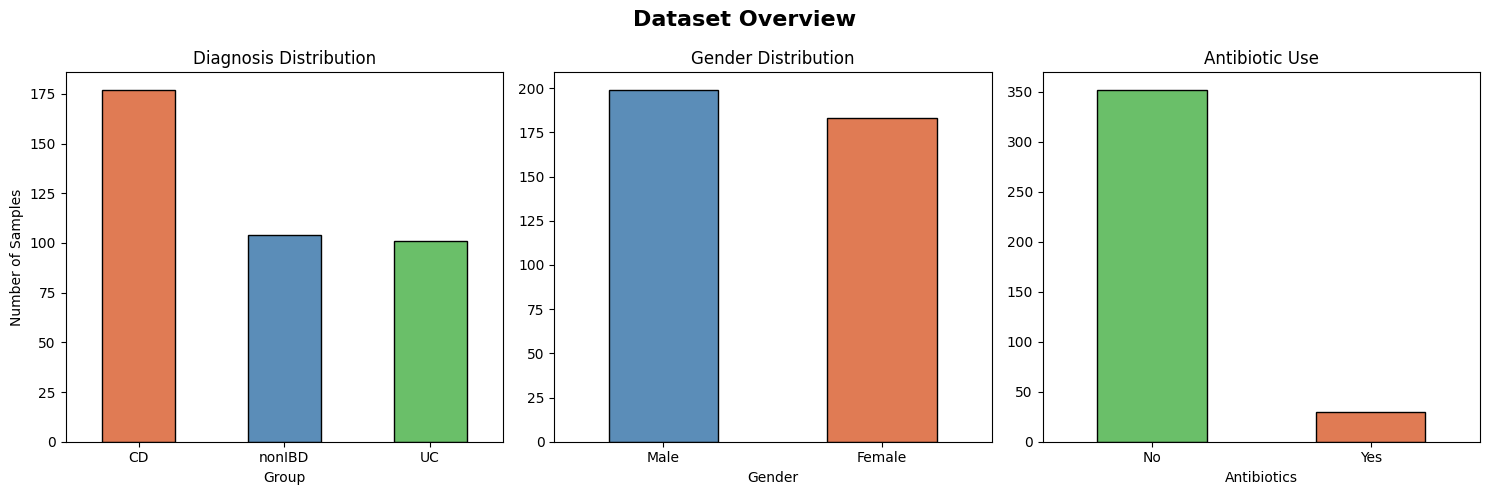

In [ ]:
# plots for the dataset overview

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Dataset Overview", fontsize=16, fontweight="bold")

# Diagnosis
meta["Study.Group"].value_counts().plot(kind="bar", ax=axes[0], color=["#e07b54","#5b8db8","#6abf69"], edgecolor="black")
axes[0].set_title("Diagnosis Distribution")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x', rotation=0)

# Gender
meta["Gender"].value_counts().plot(kind="bar", ax=axes[1], color=["#5b8db8","#e07b54"], edgecolor="black")
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].tick_params(axis='x', rotation=0)

# Antibiotics
meta["Antibiotics"].value_counts().plot(kind="bar", ax=axes[2], color=["#6abf69","#e07b54"], edgecolor="black")
axes[2].set_title("Antibiotic Use")
axes[2].set_xlabel("Antibiotics")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("../results/figures/01_dataset_overview.png", dpi=150)
plt.show()

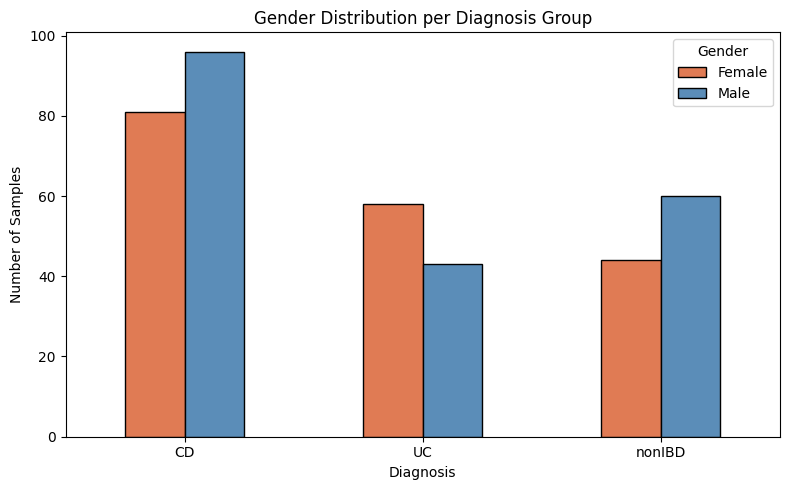

In [3]:
# plot gender split per diagnosis group

fig, ax = plt.subplots(figsize=(8, 5))

cross = pd.crosstab(meta["Study.Group"], meta["Gender"])
cross.plot(kind="bar", ax=ax, color=["#e07b54","#5b8db8"], edgecolor="black")

ax.set_title("Gender Distribution per Diagnosis Group")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', rotation=0)
ax.legend(title="Gender")

plt.tight_layout()
plt.savefig("../results/figures/02_gender_per_diagnosis.png", dpi=150)
plt.show()

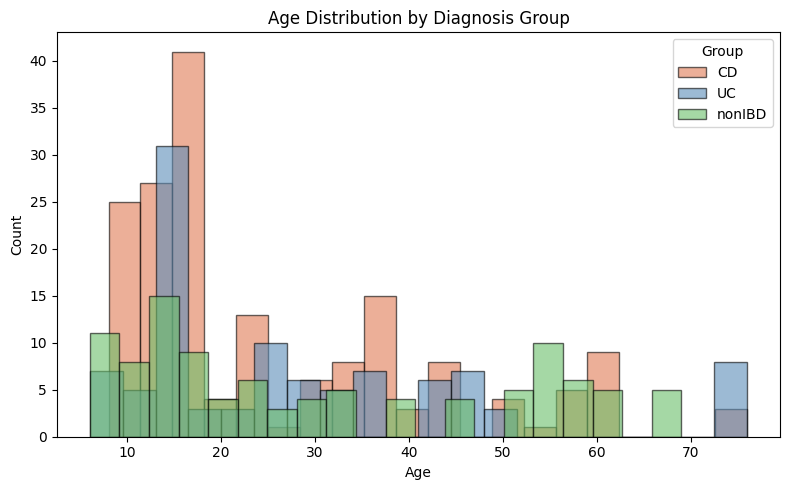

In [4]:
# plot age distribution by group

fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["CD","UC","nonIBD"], ["#e07b54","#5b8db8","#6abf69"]):
    subset = meta[meta["Study.Group"] == group]["consent_age"].dropna()
    ax.hist(subset, bins=20, alpha=0.6, label=group, color=color, edgecolor="black")

ax.set_title("Age Distribution by Diagnosis Group")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(title="Group")

plt.tight_layout()
plt.savefig("../results/figures/03_age_distribution.png", dpi=150)
plt.show()

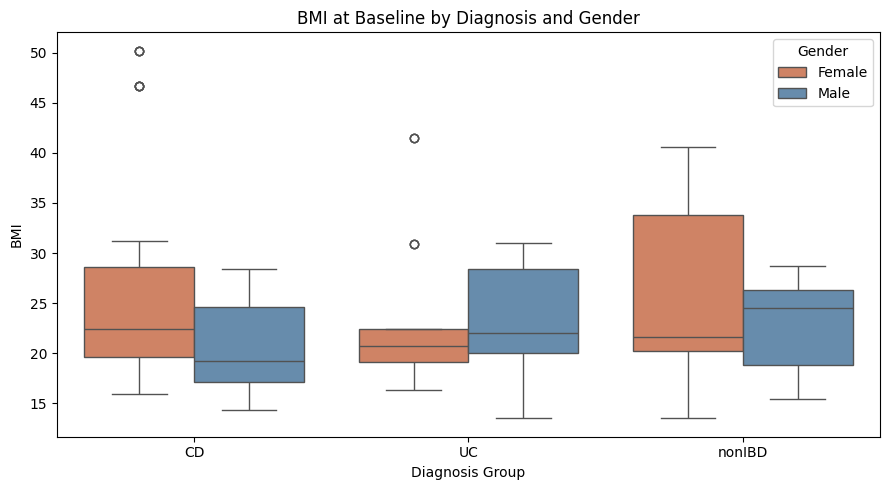

In [5]:
# plot BMI by gender and diagnosis

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=meta, x="Study.Group", y="BMI_at_baseline", hue="Gender",
            palette={"Male": "#5b8db8", "Female": "#e07b54"}, ax=ax)

ax.set_title("BMI at Baseline by Diagnosis and Gender")
ax.set_xlabel("Diagnosis Group")
ax.set_ylabel("BMI")
ax.legend(title="Gender")

plt.tight_layout()
plt.savefig("../results/figures/04_bmi_by_group_gender.png", dpi=150)
plt.show()

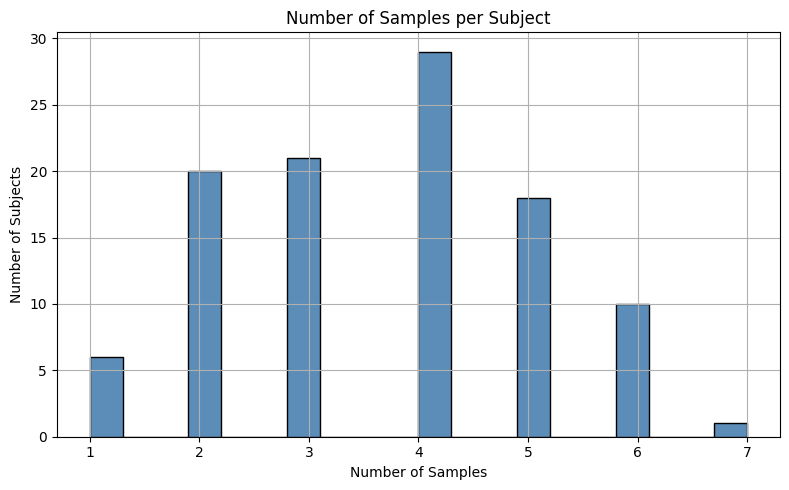

Total subjects: 105
Total samples: 382
Avg samples per subject: 3.6
Max samples from one subject: 7


In [ ]:
# how many samples per person plot 
# before proceeding with the analysis we need to know the number of samples for each person

samples_per_subject = meta.groupby("Subject")["Sample"].count()

fig, ax = plt.subplots(figsize=(8, 5))
samples_per_subject.hist(bins=20, ax=ax, color="#5b8db8", edgecolor="black")
ax.set_title("Number of Samples per Subject")
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Number of Subjects")

plt.tight_layout()
plt.savefig("../results/figures/05_samples_per_subject.png", dpi=150)
plt.show()

print(f"Total subjects: {meta['Subject'].nunique()}")
print(f"Total samples: {len(meta)}")
print(f"Avg samples per subject: {samples_per_subject.mean():.1f}")
print(f"Max samples from one subject: {samples_per_subject.max()}")

In [8]:
# Keep only the first visit per subject (baseline sample)
meta_baseline = meta.sort_values("week_num").groupby("Subject").first().reset_index()

print(f"Original samples: {len(meta)}")
print(f"Unique subjects (baseline only): {len(meta_baseline)}")
print(f"\nDiagnosis counts:\n{meta_baseline['Study.Group'].value_counts()}")
print(f"\nGender counts:\n{meta_baseline['Gender'].value_counts()}")

# Align genera table to baseline samples only
genera_baseline = genera.loc[meta_baseline["Sample"].values]

print(f"\nBaseline genera shape: {genera_baseline.shape}")

# Save for use in next notebooks
meta_baseline.to_csv("../data/processed/metadata_baseline.tsv", sep="\t", index=False)
genera_baseline.to_csv("../data/processed/genera_baseline.tsv", sep="\t")

print("\nSaved to data/processed/")

Original samples: 382
Unique subjects (baseline only): 105

Diagnosis counts:
Study.Group
CD        49
UC        30
nonIBD    26
Name: count, dtype: int64

Gender counts:
Gender
Male      53
Female    52
Name: count, dtype: int64

Baseline genera shape: (105, 9694)

Saved to data/processed/


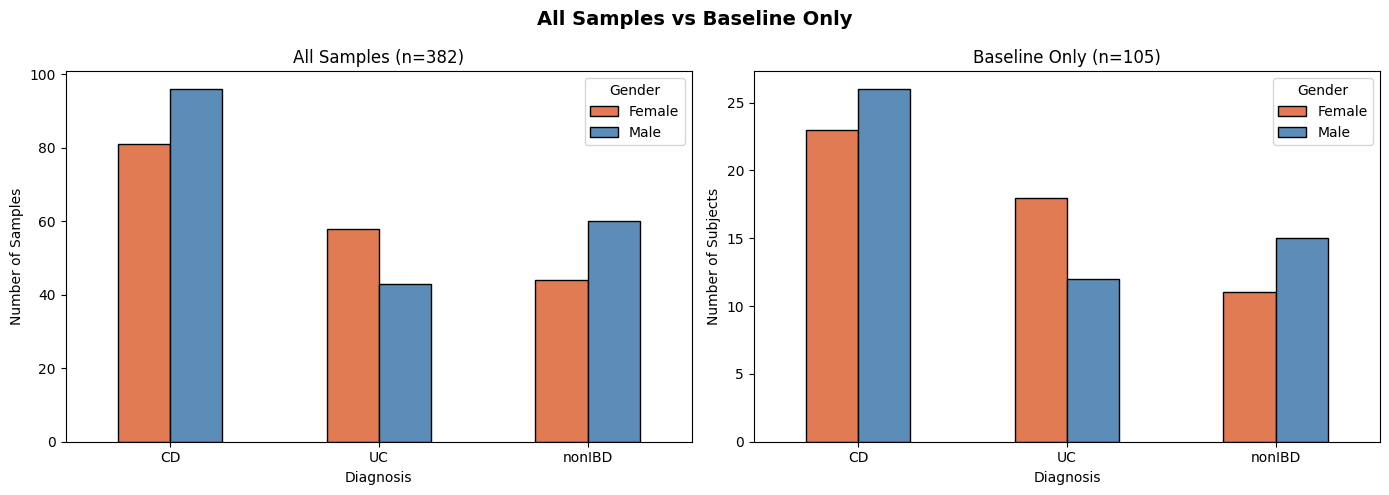

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("All Samples vs Baseline Only", fontsize=14, fontweight="bold")

# --- Left: All samples ---
cross_all = pd.crosstab(meta["Study.Group"], meta["Gender"])
cross_all.plot(kind="bar", ax=axes[0], color=["#e07b54","#5b8db8"], edgecolor="black")
axes[0].set_title(f"All Samples (n={len(meta)})")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title="Gender")

# --- Right: Baseline only ---
cross_base = pd.crosstab(meta_baseline["Study.Group"], meta_baseline["Gender"])
cross_base.plot(kind="bar", ax=axes[1], color=["#e07b54","#5b8db8"], edgecolor="black")
axes[1].set_title(f"Baseline Only (n={len(meta_baseline)})")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Number of Subjects")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Gender")

plt.tight_layout()
plt.savefig("../results/figures/06_all_vs_baseline.png", dpi=150)
plt.show()